In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fmpy import simulate_fmu
import os, zipfile

In [2]:
# Pfad zu deiner FMU-Datei
fmu_path = r"C:/Users/simin.sis/AppData/Local/Temp/OpenModelica/OMEdit/FMU_Speicher_240a2/FMU_Speicher_2.fmu"

In [3]:
print("Existiert Datei?", os.path.isfile(fmu_path))
print("Größe (Bytes):", os.path.getsize(fmu_path) if os.path.exists(fmu_path) else "—")
print("Ist ZIP?", zipfile.is_zipfile(fmu_path) if os.path.isfile(fmu_path) else "—")

Existiert Datei? True
Größe (Bytes): 676906
Ist ZIP? True


In [4]:
# Simulationszeit
t0 = 0.0
t1 = 5.0
dt = 0.001
time = np.arange(t0, t1 + dt, dt)

In [5]:
time.size # oder len(time)

5001

In [6]:
# Definiere eine Eingangstrajektorie u(t)
# Beispiel: Sinus (0.5 Hz)
u = 2000*np.sin(2 * np.pi * 0.5 * time)

In [7]:
# FMPy erwartet ein strukturiertes Array mit Feldern 'time' und '<signalname>'
# Der Signalname muss exakt dem FMU-Variablennamen entsprechen (hier: 'u')
input_data = np.zeros(time.shape[0], dtype=[('time', np.double), ('u', np.double)])
input_data['time'] = time
input_data['u'] = u

In [8]:
# Simulation starten
result = simulate_fmu(
    fmu_path,
    start_time=t0,
    stop_time=t1,
    #step_size=dt,
    output_interval=dt,
    input=input_data,
    #output=['y']       # Wir wollen 'y' im Ergebnis
    output=['y', 'E', 'SOC']
)

In [9]:
# result ist ein strukturiertes Array mit u.a. 'time' und 'y'
t = result['time']
y = result['y']
E = result['E']
SOC = result['SOC']

In [10]:
t.size

5001

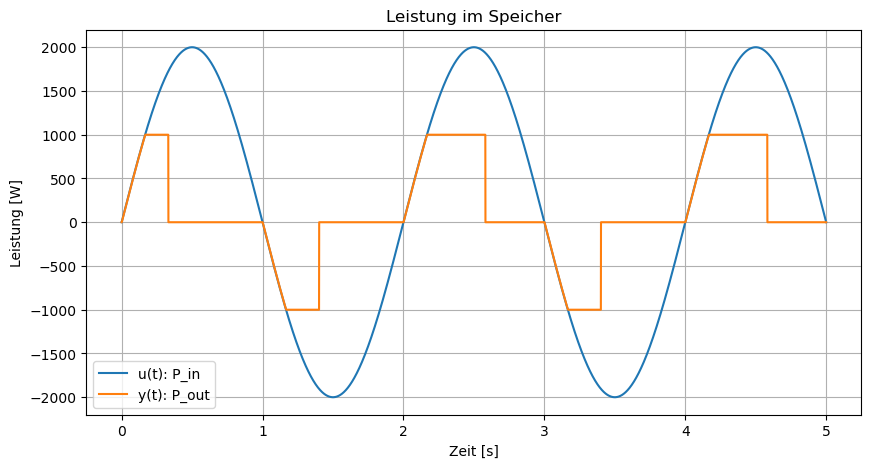

In [11]:
# Plot
#plt.figure()
plt.figure(figsize=(10, 5))
plt.plot(t, input_data['u'], label='u(t): P_in')
plt.plot(t, y, label='y(t): P_out')
plt.xlabel('Zeit [s]')
plt.ylabel('Leistung [W]')
plt.title('Leistung im Speicher')
plt.legend()
plt.grid(True)
plt.show()

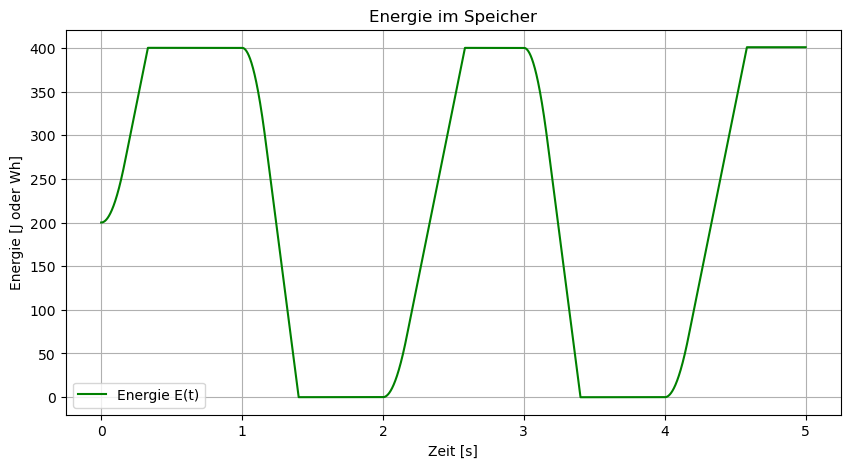

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(t, E, label='Energie E(t)', color='green')
plt.xlabel('Zeit [s]')
plt.ylabel('Energie [J oder Wh]')
plt.title('Energie im Speicher')
plt.legend()
plt.grid(True)
plt.show()

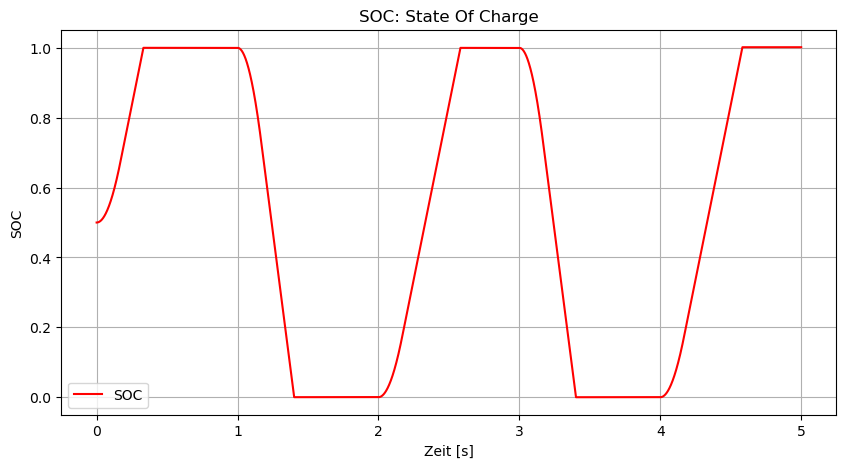

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(t, SOC, label='SOC', color='red')
plt.xlabel('Zeit [s]')
plt.ylabel('SOC')
plt.title('SOC: State Of Charge')
plt.legend()
plt.grid(True)
plt.show()